In [12]:
import pandas as pd
from src.preprocessing import preprocess_data
import matplotlib.pyplot as plt

In [17]:

sales = pd.read_csv(r'C:\Users\m_kal\Downloads\datasets\rossmann-store-sales\train.csv')
stores = pd.read_csv(r'C:\Users\m_kal\Downloads\datasets\rossmann-store-sales\store.csv')

df = preprocess_data(sales, stores)

df.head()

C:\Users\m_kal\AppData\Local\Temp\ipykernel_20440\379391245.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv(r'C:\Users\m_kal\Downloads\datasets\rossmann-store-sales\train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StoreType,Assortment,CompetitionDistance,Promo2,PromoInterval,Promo2SinceDate,CompetitionStartDate,isStateHoliday,isSchoolHoliday
1016095,1,2,2013-01-01,0,0,0,0,c,a,1270.0,0,NaN,NaT,2008-02-25,True,True
1014980,1,3,2013-01-02,5530,668,1,0,c,a,1270.0,0,NaN,NaT,2008-02-25,False,True
1013865,1,4,2013-01-03,4327,578,1,0,c,a,1270.0,0,NaN,NaT,2008-02-25,False,True
1012750,1,5,2013-01-04,4486,619,1,0,c,a,1270.0,0,NaN,NaT,2008-02-25,False,True
1011635,1,6,2013-01-05,4997,635,1,0,c,a,1270.0,0,NaN,NaT,2008-02-25,False,True


In [18]:
df['day_name'] = df['Date'].apply(lambda x: pd.to_datetime(x).day_name())

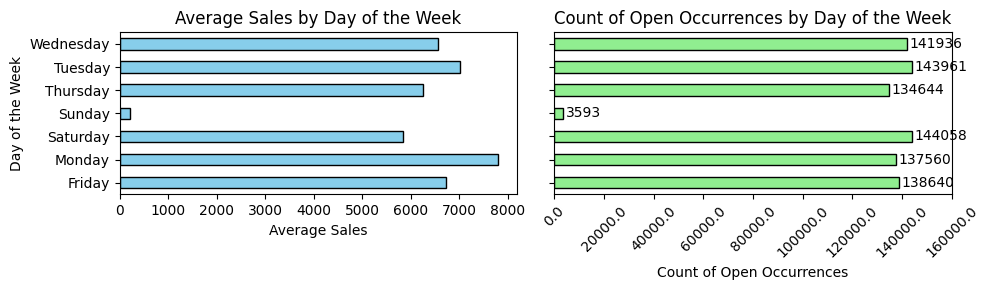

In [53]:
fig, ax = plt.subplots(figsize=(10, 3), ncols=2, sharey=True)
df.groupby('day_name')['Sales'].mean().plot(kind='barh', color='skyblue', edgecolor='black', ax=ax[0])
ax[0].set_ylabel('Day of the Week')
ax[0].set_xlabel('Average Sales')
ax[0].set_title('Average Sales by Day of the Week')

df.groupby('day_name')['Open'].sum().astype(int).plot(kind='barh', color='lightgreen', edgecolor='black', ax=ax[1])
ax[1].set_ylabel('Day of the Week')
ax[1].set_xlabel('Count of Open Occurrences')
ax[1].set_title('Count of Open Occurrences by Day of the Week')
ax[1].set_xticks(ax[1].get_xticks())
ax[1].set_xticklabels(labels=ax[1].get_xticks(), rotation=45)    
# add numbers on top of the bars for the second plot
for i, v in enumerate(df.groupby('day_name')['Open'].sum().astype(int)):
    ax[1].text(v + 1000, i, str(v), color='black', va='center')
# add a tight layout to prevent overlapping labels
plt.tight_layout()
plt.show()

For the vast majority of Sundays, we have closed stores, apart from a very small number of occurences in which stores are open on Sundays.
Perhaps these are holidays?

In [48]:
print("Total Open Store Occurrences on Sundays by State Holiday Status:")
df.loc[df['day_name'] == 'Sunday', :].groupby('Open')['isStateHoliday'].sum()

Total Open Store Occurrences on Sundays by State Holiday Status:


Open
0    307
1      2
Name: isStateHoliday, dtype: int64

In [55]:
print("Records with open stores on Sundays that are state holidays:")
filter = (df['day_name'] == 'Sunday') & (df['isStateHoliday'] == 1) & (df['Open'] == 1)
df.loc[filter, ['Date', 'day_name', 'Store', 'Sales']]

Records with open stores on Sundays that are state holidays:


,Date,day_name,Store,Sales
1010872,2013-01-06,Sunday,353,3930
1011467,2013-01-06,Sunday,948,6024


<Axes: ylabel='day_name'>

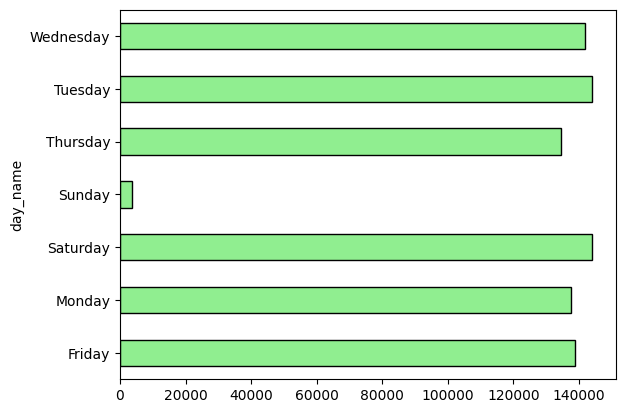

In [22]:
df.groupby('day_name')['Open'].sum().plot(kind='barh', color='lightgreen', edgecolor='black')

In [ ]:
hdf_all = df_all[['Store', 'Date', 'isStateHoliday', 'isSchoolHoliday', 'Sales']]
hdf_all['day_name'] = hdf_all['Date'].apply(lambda x: pd.to_datetime(x).day_name())
hdf_all = hdf_all.loc[hdf_all['isStateHoliday']]

In [ ]:
pdz = (hdf_all['Sales'] == 0).sum() / len(hdf_all) * 100 # Proportion of holiday days with zero sales
print(f"Proportion of holiday days with zero sales: {pdz:.2f}%")
pdnz = (hdf_all['Sales'] > 0).sum() / len(hdf_all) * 100 # Proportion of holiday days with non-zero sales
print(f"Proportion of holiday days with non-zero sales: {pdnz:.2f}%")

In [ ]:
# Gather all holiday days with non-zero sales for further analysis
hdf = hdf_all.loc[hdf_all['Sales'] > 0].copy()
hdf['month'] = hdf['Date'].apply(lambda x: pd.to_datetime(x).month_name())
hdf['month_day'] = hdf['Date'].apply(lambda x: pd.to_datetime(x).strftime('%B %d - %A'))  # Format as "Month Day - Day Name"
print('Holiday days with non-zero sales:')
hdf.head(5)

In [ ]:
display(hdf.groupby('month_day')['Store'].count().sort_index())